# IMPORT

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR,
 CLAUDE_CLADE_DIR, TREE_NWK,

    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [ ]:
import sys, os
# os.chdir removed by plot_revision refactor
if '/homes/gws/yongkang/HiC/Evo2HiC' not in sys.path:
    sys.path.insert(0, '/homes/gws/yongkang/HiC/Evo2HiC')


In [2]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches


import plot_utils
reload(plot_utils)

from plot_settings import *
from plot_utils import *

from scipy.stats import gaussian_kde, spearmanr, pearsonr
import matplotlib.gridspec as gridspec


plt.style.use('seaborn-v0_8-white')


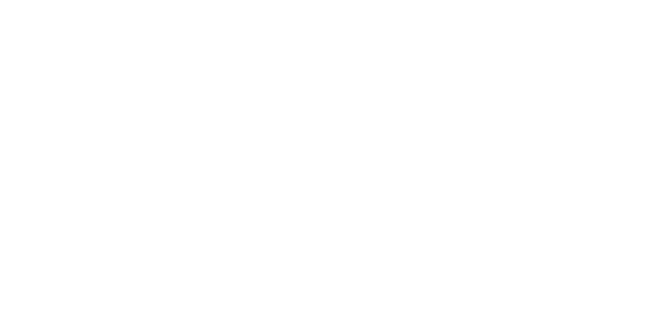

In [3]:
fig = plt.figure(figsize=(8.27, 4))

gs = gridspec.GridSpec(
    2, 7,
    figure=fig,
    height_ratios=[1,1],
    width_ratios=[1.8, 0.4, 0.8, 0.2, 1.2, 0.1, 1.2],
    hspace=0.3,
    wspace=0.0,
    left=0.08
)

axes = []
for i, row in enumerate([0,1]):   
    row_axes = []
    for j, col in  enumerate([0,2,4,6]):
        ax = fig.add_subplot(gs[row, col])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# fig.tight_layout()

In [4]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])

xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 1. Prepare Seq2HiC

In [5]:
hicname = {
    'H1ESC' : '4DNFI2TK7L2F',
    'HFF' : '4DNFIPC7P27B'
}

## get target

In [6]:
import dataset.hic_loader
reload(dataset.hic_loader)
from dataset.hic_loader import HiC_Loader 

resolution = 4000
base_resolution = 2000
D = resolution // base_resolution

targets_ = {}
regions_ = {}

for cell in hicname.keys():
    hic_loader = HiC_Loader(f'/m-chimera/chimera/nobackup/yongkang/HiC_data/data/hic/raw_hic/{hicname[cell]}.hic', resolution=base_resolution)
    targets = []
    regions = []

    chr_num = {
        8 : 200,
        9 : 213,
        10 : 204
    }

    test_chr = [9, 10]

    for c in test_chr:
        for i in range(chr_num[c]):
            pos = 16000000 + i*500000
            sf,ef = pos-16000000, pos+16000000
            start = (62)*32+(62)*16+(62)*8+(62)*4+(62)*2

            lpad, rpad = 20, 10
            s,e = sf+(start-lpad) * resolution, sf+(start+250+rpad) * resolution

            target = hic_loader.get(c, s, e, 0, c, s, e, 0, norm=True).astype(np.float32)

            d0, d1 = target.shape[-1]//D, target.shape[-2]//D
            target = np.sum(np.reshape(target, (-1, d0, D, d1, D)), axis=(-1, -3))

            target = target[0, lpad:-rpad, lpad:-rpad]
            targets.append(target)

            regions.append((sf+(start) * resolution, sf+(start+250) * resolution))

            # norm = hic_loader.norm_vectors[f'{c}'][s//hic_loader.resolution:e//hic_loader.resolution]
            # norm = np.mean(np.reshape(norm, (-1, D)), axis=-1)
            # norm = norm[lpad:-rpad]
            # norms.append(norm)

    targets = np.array(targets)
    targets_[cell] = targets
    regions_[cell] = regions

## get orca pred

In [7]:
orca_allpreds = torch.load(str(ORCA_MALLPREDS_PTH), map_location='cpu')

raw_orca_preds_ = {}

for cell in hicname.keys():
    orca_preds = []
    for i in range(len(orca_allpreds)):
        for j in range(1):
            p1 = orca_allpreds[i][0 if cell=='H1ESC' else 1][j].detach().cpu().numpy()[0,0,:,:]+\
                orca_allpreds[i][2 if cell=='H1ESC' else 3][j].detach().cpu().numpy()[0,0,::-1,::-1]

            orca_preds.append(p1)

    orca_preds = np.array(orca_preds)

    normmat_bydist = np.exp(
        np.load(str(ORCA_EXPECTED_NPY))
    )[:250]
    normmat = normmat_bydist[np.abs(np.arange(250)[:, None] - np.arange(250)[None, :])]
    eps = np.min(normmat)
    raw_orca_preds = np.exp(orca_preds) * (normmat+eps)-eps

    mask = np.isfinite(targets)
    r0 = np.sum(targets[mask]) / np.sum(raw_orca_preds[mask])
    raw_orca_preds = raw_orca_preds * r0

    raw_orca_preds_[cell] = raw_orca_preds

# 1. Inference Seq2HiC

In [8]:
ckpt_base = str(CKPT_ROOT / 'seq2hic')
ckpts = {
    'H1ESC' : {
        'evohic': f'{ckpt_base}/H1ESC/evo2hic/model.pt',
        'evo' : f'{ckpt_base}/H1ESC/evo2/model.pt'
    },
    'HFF':{
        'evohic': f'{ckpt_base}/HFF/evo2hic/model.pt',
        'evo' : f'{ckpt_base}/HFF/evo2/model.pt'
    }
}

## infer evohic

In [9]:
from inference.inference_CDNA2d import load_model
from dataset.DNA_loader import DNA_Loader
from dataset.mappability_loader import Mappability_Loader
from config import *
from tqdm import tqdm

DNA_loader = DNA_Loader(DNA_map['human'], 'Yes')
mappability_loader = Mappability_Loader(mappability_map['human'], 'Yes')

evohic_preds_ = {}
for cell in hicname.keys():

    model, modelargs, normalizer = load_model(ckpts[cell]['evohic'])

    device = 'cuda:0'
    evohic_preds = []

    model.to(device)
    model.eval()

    for c in test_chr:
        for i in range(chr_num[c]):
            pos = 16000000 + i*500000
            sf,ef = pos-16000000, pos+16000000
            start = (62)*32+(62)*16+(62)*8+(62)*4+(62)*2

            lpad, rpad = 20, 10
            s,e = sf+(start-lpad) * resolution, sf+(start+250+rpad) * resolution

            pred_st = []

            for st in [0,1]:
                DNA_row = DNA_loader.get(c, s, e, st).astype(np.float32)
                mappability_row = mappability_loader.get(c, s, e, st).astype(np.float32)

                input_matrix = hic_loader.get_expected(c, s, e, st, c, s, e, st).astype(np.float32)
                d0, d1 = input_matrix.shape[-1]//D, input_matrix.shape[-2]//D
                input_matrix = np.sum(np.reshape(input_matrix, (-1, d0, D, d1, D)), axis=(-1, -3))

                input_matrix = normalizer.normalize(input_matrix).clip(max=1)
                DNA_row = torch.tensor(DNA_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
                mappability_row = torch.tensor(mappability_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
                input_matrix = torch.tensor(input_matrix).unsqueeze(0).unsqueeze(0).unsqueeze(0)

                DNA_row = DNA_row.to(device)
                mappability_row = mappability_row.to(device)
                input_matrix = input_matrix.to(device)

                with torch.no_grad():
                    pred = model(input_matrix = input_matrix, DNA_col = None, DNA_row=DNA_row, mappability_col=None, mappability_row=mappability_row)

                pred_st.append((pred + pred.transpose(-1, -2))/2)
            pred = ((pred_st[0]+pred_st[1].flip((-1, -2)))/2).squeeze()
            pred = pred[lpad:-rpad, lpad:-rpad]

            pred = normalizer.unnormalize(pred, tensor=True)
            evohic_preds.append(pred.cpu().detach().numpy())

    evohic_preds = np.array(evohic_preds)
    evohic_preds_[cell] = evohic_preds


/homes/gws/yongkang/anaconda3/envs/Evo2HiC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:root:Creating model


Creating model


INFO:root:Model created. Number of parameters: 81034775


Model created. Number of parameters: 81034775


INFO:root:Creating model


Creating model


INFO:root:Model created. Number of parameters: 81034775


Model created. Number of parameters: 81034775


## Infer noevo (deprecated)

In [10]:
# from inference.inference_CDNA2d import load_model
# from dataset.DNA_loader import DNA_Loader
# from dataset.mappability_loader import Mappability_Loader
# from config import *
# from tqdm import tqdm

# DNA_loader = DNA_Loader(DNA_map['human'], 'Yes')
# mappability_loader = Mappability_Loader(mappability_map['human'], 'Yes')

# model, modelargs, normalizer = load_model(ckpts[cell]['noevo'])

# device = 'cuda:0'
# noevo_preds = []

# model.to(device)
# model.eval()

# for c in test_chr:
#     for i in range(chr_num[c]):
#         pos = 16000000 + i*500000
#         sf,ef = pos-16000000, pos+16000000
#         start = (62)*32+(62)*16+(62)*8+(62)*4+(62)*2

#         lpad, rpad = 20, 10
#         s,e = sf+(start-lpad) * resolution, sf+(start+250+rpad) * resolution

#         pred_st = []

#         for st in [0,1]:
#             DNA_row = DNA_loader.get(c, s, e, st).astype(np.float32)
#             mappability_row = mappability_loader.get(c, s, e, st).astype(np.float32)

#             input_matrix = hic_loader.get_expected(c, s, e, st, c, s, e, st).astype(np.float32)
#             d0, d1 = input_matrix.shape[-1]//D, input_matrix.shape[-2]//D
#             input_matrix = np.sum(np.reshape(input_matrix, (-1, d0, D, d1, D)), axis=(-1, -3))

#             input_matrix = normalizer.normalize(input_matrix).clip(max=1)
#             DNA_row = torch.tensor(DNA_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
#             mappability_row = torch.tensor(mappability_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
#             input_matrix = torch.tensor(input_matrix).unsqueeze(0).unsqueeze(0).unsqueeze(0)

#             DNA_row = DNA_row.to(device)
#             mappability_row = mappability_row.to(device)
#             input_matrix = input_matrix.to(device)

#             with torch.no_grad():
#                 pred = model(input_matrix = input_matrix, DNA_col = None, DNA_row=DNA_row, mappability_col=None, mappability_row=mappability_row)

#             pred_st.append((pred + pred.transpose(-1, -2))/2)
#         pred = ((pred_st[0]+pred_st[1].flip((-1, -2)))/2).squeeze()
#         pred = pred[lpad:-rpad, lpad:-rpad]

#         pred = normalizer.unnormalize(pred, tensor=True)
#         noevo_preds.append(pred.cpu().detach().numpy())

# noevo_preds = np.array(noevo_preds)


## Infer Evo

In [ ]:
from inference.inference_CDNA2d import load_model, load_evo_encoder
from dataset.evo2_embedding_loader import evo2_Embedding_Loader
from config import *
from tqdm import tqdm

embedding_loader = evo2_Embedding_Loader(evo2_embedding_map['human'], 'Yes')

evo_preds_ = {}
for cell in hicname.keys():

    model, modelargs, normalizer = load_model(ckpts[cell]['evo'])

    evo_encoder = load_evo_encoder(ckpts[cell]['evo'])

    device = 'cuda:0'
    evo_preds = []

    model.to(device)
    model.eval()

    evo_encoder.to(device)
    evo_encoder.eval()

    for c in test_chr:
        for i in range(chr_num[c]):
            pos = 16000000 + i*500000
            sf,ef = pos-16000000, pos+16000000
            start = (62)*32+(62)*16+(62)*8+(62)*4+(62)*2

            lpad, rpad = 20, 10
            s,e = sf+(start-lpad) * resolution, sf+(start+250+rpad) * resolution

            pred_st = []

            for st in [0,1]:
                embedding_row = embedding_loader.get(c, s, e, st).astype(np.float32)
                mappability_row = mappability_loader.get(c, s, e, st).astype(np.float32)

                input_matrix = hic_loader.get_expected(c, s, e, st, c, s, e, st).astype(np.float32)
                d0, d1 = input_matrix.shape[-1]//D, input_matrix.shape[-2]//D
                input_matrix = np.sum(np.reshape(input_matrix, (-1, d0, D, d1, D)), axis=(-1, -3))

                input_matrix = normalizer.normalize(input_matrix).clip(max=1)
                embedding_row = torch.tensor(embedding_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
                mappability_row = torch.tensor(mappability_row).unsqueeze(0).unsqueeze(0).unsqueeze(0)
                input_matrix = torch.tensor(input_matrix).unsqueeze(0).unsqueeze(0).unsqueeze(0)

                embedding_row = embedding_row.to(device)
                mappability_row = mappability_row.to(device)
                input_matrix = input_matrix.to(device)

                with torch.no_grad():
                    Evo_embeds = evo_encoder(embedding0=None, embedding1=embedding_row, mappability0=None, mappability1 = mappability_row)
                    pred = model(input_matrix = input_matrix, DNA_embeds=Evo_embeds)

                pred_st.append((pred + pred.transpose(-1, -2))/2)
            pred = ((pred_st[0]+pred_st[1].flip((-1, -2)))/2).squeeze()
            pred = pred[lpad:-rpad, lpad:-rpad]

            pred = normalizer.unnormalize(pred, tensor=True)
            evo_preds.append(pred.cpu().detach().numpy())

    evo_preds = np.array(evo_preds)
    evo_preds_[cell]=evo_preds

# 2. Eval Seq2HiC

## SPC by distance

In [ ]:
eval_resolution = 4000

In [ ]:
def group_by_diagonal_offset(batch_arr):
    """
    Transform a batched (b, N, N) array into lists grouped by diagonal offset (y - x).
    Returns a list of arrays, one for each offset from -(N-1) to N-1.
    Each element in the output is of shape (b, count_at_offset).
    """
    if eval_resolution != resolution:
        ds = eval_resolution // resolution
        _, N, _ = batch_arr.shape
        batch_arr = np.sum(np.reshape(batch_arr, (-1, N//ds, ds, N//ds, ds)), axis=(-1, -3))
    _, N, _ = batch_arr.shape
    result = []

    for d in range(0, N):  
        vals = np.diagonal(batch_arr, d, axis1=-2, axis2=-1)
        result.append(vals)

    return result  # List of arrays of shape (b, variable length)

def get_spcs(pred_diags, target_diags):
    spcs = []

    for p, t in zip(pred_diags, target_diags):
        mask = np.isfinite(t)
        spcs.append(spearmanr(p[mask].flatten(), t[mask].flatten())[0])

    return spcs

def get_pccs(pred_diags, target_diags):
    spcs = []

    for p, t in zip(pred_diags, target_diags):
        mask = np.isfinite(t)
        spcs.append(pearsonr(p[mask].flatten(), t[mask].flatten())[0])

    return spcs

dfs = {}

for cell in hicname.keys():
    orca_pred_diags = group_by_diagonal_offset(raw_orca_preds_[cell])
    evohic_pred_diags = group_by_diagonal_offset(evohic_preds_[cell])
    evo_pred_diags = group_by_diagonal_offset(evo_preds_[cell])

    target_diags = group_by_diagonal_offset(targets_[cell])

    orca_spcs = get_spcs(orca_pred_diags, target_diags)
    evohic_spcs = get_spcs(evohic_pred_diags, target_diags)
    evo_spcs = get_spcs(evo_pred_diags, target_diags)

    print(cell)
    print(np.mean(evohic_spcs))
    print(np.mean(orca_spcs))
    print(np.mean(evo_spcs))

    imp = np.mean(evohic_spcs)/np.mean(orca_spcs)-1
    print(imp)

    grouping = []
    group_length = len(evohic_spcs)//5
    for i in range(0, len(evohic_spcs), group_length):
        grouping.extend([f'{i*(eval_resolution/1000000):.1f}-{(i+group_length)*(eval_resolution/1000000):.1f}']*group_length)

    remove_diag = 5

    df_evohic = pd.DataFrame({
        'Method': ['Evo2HiC']* (len(evohic_spcs)-remove_diag),
        'Metric': grouping[remove_diag:],
        'Value': evohic_spcs[remove_diag:]
    })
    df_noevo = pd.DataFrame({
        'Method': ['Evo 2']* (len(evo_spcs) - remove_diag),
        'Metric': grouping[remove_diag:],
        'Value': evo_spcs[remove_diag:]
    })

    df_orca = pd.DataFrame({
        'Method': ['Orca']* (len(orca_spcs) - remove_diag),
        'Metric': grouping[remove_diag:],
        'Value': orca_spcs[remove_diag:]
    })

    df = pd.concat([df_evohic, df_orca, df_noevo])
    dfs[cell] = df

H1ESC
0.4576699705716417
0.3989178864288013
0.3679709629224138
0.1472786408972575
HFF
0.4500315155943178
0.4200001451513019
0.39418733744676965
0.0715032382481613


In [ ]:
clear_test_log()
plot_grouped_box_with_points(
    dfs['H1ESC'], ax=axes[0][0], methods=['Evo2HiC', 'Orca', 'Evo 2'], box_width=0.22, colors=colors, ylabel='SPC', ymin=0.2,
    pairs_per_group=[('Evo2HiC', 'Orca')]*4+[('Evo2HiC', 'Evo 2')], alternative='greater', arm_frac=0.03, pad_frac=0.03,
    log_panel='Fig3a_H1ESC_SPCbyDistance')
plot_grouped_box_with_points(
    dfs['HFF'],   ax=axes[1][0], methods=['Evo2HiC', 'Orca', 'Evo 2'], box_width=0.22, colors=colors, xlabel='Distance (Mb)', ylabel='SPC', show_xticks=True, ymin=0.2,
    pairs_per_group=[('Evo2HiC', 'Orca')]*5, alternative='greater', arm_frac=0.03, pad_frac=0.03,
    log_panel='Fig3e_HFF_SPCbyDistance')
fig

In [ ]:
print('EvoHiC-Orca vs Dis: ', spearmanr(np.array(evohic_spcs) - np.array(orca_spcs), np.arange(len(evohic_spcs)))[0])
print('Evo2-EvoHiC vs Dis: ', spearmanr(np.array(evo_spcs) - np.array(evohic_spcs), np.arange(len(evohic_spcs)))[0])
print('Evo2-EvoHiC vs Dis: ', spearmanr(np.array(evo_spcs) - np.array(orca_spcs), np.arange(len(evohic_spcs)))[0])

EvoHiC-Orca vs Dis:  0.4317753564057024
Evo2-EvoHiC vs Dis:  0.7913610137762204
Evo2-EvoHiC vs Dis:  0.8418439975039599


## TAD

In [ ]:
import cooler
from cooltools.api.insulation import calculate_insulation_score, find_boundaries
import logging
logging.getLogger().setLevel(logging.ERROR)

# -------------------------------
# 1) 把 1Mb*1Mb 局部矩阵写成 .cool
# -------------------------------
def write_local_cool(M: np.ndarray, res: int, cool_path: str, chrom_name: str = "chrR"):
    """
    将局部方阵 M (N x N) 写为一个最小可用 .cool 文件。
    假设区域长度 = N * res（例如 1Mb），坐标从 0 开始。
    """
    assert M.shape[0] == M.shape[1], "M must be square."
    N = M.shape[0]
    region_len = N * res

    # 构 bins 表
    starts = np.arange(0, region_len, res, dtype=np.int64)
    ends = starts + res
    bins = pd.DataFrame({"chrom": chrom_name, "start": starts, "end": ends})

    # 仅存上三角（含主对角）
    i, j = np.triu_indices(N, k=0)
    counts = M[i, j].astype(float)
    # 过滤掉无效/0像素（可按需调整）
    mask = np.isfinite(counts) & (counts != 0)
    pixels = pd.DataFrame({
        "bin1_id": i[mask].astype(np.int64),
        "bin2_id": j[mask].astype(np.int64),
        "count":   counts[mask]
    })

    # 写 cooler
    cooler.create_cooler(
        cool_path,
        bins=bins,
        pixels=pixels,
        dtypes={"count": "float64"},
        ordered=True,   # 要求像素按 bin1 分组且 i<=j，会更快
    )
    return cool_path

# -------------------------------------------
# 2) 调 cooltools 的 diamond_insulation (API)
# -------------------------------------------
def run_insulation_api(cool_path: str,
                       window_bp: int = 100_000,
                       ignore_diags: int = 2,
                       balance: bool = False):
    """
    对指定 .cool 运行 diamond insulation，返回 (is_table, chosen_cols)。
    is_table：包含每个 bin 的 log2(insulation) / prominence / is_boundary 等列。
    chosen_cols：一个 dict，给出当前 window 对应列名。
    """
    clr = cooler.Cooler(cool_path)

    # 注意：对 1Mb 局部数据一般没有可用的 weights；设 balance=False 避免误用
    ins_table = calculate_insulation_score(
        clr,
        window_bp=[int(window_bp)], 
        ignore_diags=ignore_diags,
        clr_weight_name=None,
    )

    ins_table = find_boundaries(ins_table)

    # 自动解析列名（不同版本命名略有差异）
    # 典型列名：log2_insulation_score_100000, is_boundary_100000, prominence_100000
    wtag = str(window_bp)
    def pick(col_prefix):
        cands = [c for c in ins_table.columns if c.startswith(col_prefix)]
        # 优先匹配含窗口后缀的列
        tagged = [c for c in cands if c.endswith(wtag)]
        return (tagged[0] if tagged else (cands[0] if cands else None))
    
    col_log2  = pick("log2_insulation_score")
    col_prom  = pick("boundary_strength")

    if col_log2 is None:
        raise RuntimeError("Cannot find log2_insulation_score column in output.")
    if col_prom is None:
        raise RuntimeError("Cannot find prominence column in output.")

    chosen_cols = {"log2": col_log2, "prominence": col_prom}
    return ins_table, chosen_cols

# ----------------------------------------------------
# 3) 从结果表中抽取：insulation score 向量 & boundary
# ----------------------------------------------------
def extract_scores_and_boundaries(is_table: pd.DataFrame,
                                  cols: dict,
                                  prominence_cut: float = 0.2):
    """
    返回：
      - scores: np.ndarray (按 bin 顺序的 log2 insulation，含 NaN)
      - boundaries_df: DataFrame[bin_id, chrom, start, end, prominence]
      - boundaries_bins: List[int] 仅 bin 索引
    """
    # insulation score（log2域）
    scores = is_table[cols["log2"]].to_numpy().astype(float)

    # 用 prominence ≥ 阈值 判定边界（更贴近 4DN 做法）
    prom = is_table[cols["prominence"]].to_numpy().astype(float)
    is_b = np.isfinite(prom) & (prom >= float(prominence_cut))
    boundaries_df = is_table.loc[is_b, ["chrom", "start", "end"]].copy()
    boundaries_df.insert(0, "bin_id", np.where(is_b)[0].astype(int))
    boundaries_df["prominence"] = prom[is_b]

    boundaries_bins = boundaries_df["bin_id"].tolist()
    return scores, boundaries_df, boundaries_bins

# -------------------------
# 4) 一键式总管道（你用这个）
# -------------------------
def insulation_pipeline_from_matrix(
        M: np.ndarray,
        res: int = 4000,
        cool_path: str = str(REPO / "misc" / "local_1mb.cool"),
        window_bp: int = 100_000,
        ignore_diags: int = 2,
        prominence_cut: float = 0.2,
    ):
    """
    输入：局部矩阵 M（例如 1Mb/4kb -> 250x250），bin 大小 res。
    输出：scores(np.ndarray), boundaries_df(DataFrame), boundaries_bins(list)
    同时可选保存两份 TSV。
    """
    # 写 cool
    write_local_cool(M, res=res, cool_path=cool_path)

    # 跑 insulation
    is_table, cols = run_insulation_api(
        cool_path,
        window_bp=window_bp,
        ignore_diags=ignore_diags,
        balance=False
    )

    # 抽取结果
    scores, boundaries_df, boundaries_bins = extract_scores_and_boundaries(
        is_table, cols, prominence_cut=prominence_cut
    )

    return scores, boundaries_bins

In [ ]:
def bound_matching(prd_bounds, tgt_bounds, boundary_zone_size=3):
    if len(tgt_bounds) == 0:
        return np.nan, 0
    if len(prd_bounds) == 0:
        return 0, 0
    tgt_matched = np.zeros_like(tgt_bounds)
    prd_matched = np.zeros_like(prd_bounds)
    for i, pb in enumerate(prd_bounds):
        for j, tb in enumerate(tgt_bounds): 
            if abs(pb-tb)<=boundary_zone_size: 
                prd_matched[i] = 1
                tgt_matched[j] = 1

    precision = np.nan_to_num(np.mean(prd_matched))
    recall = np.nan_to_num(np.mean(tgt_matched))

    if precision == 0 or recall == 0:
        return 0, 0

    return 2/(1/precision + 1/recall), np.sum(tgt_matched)

In [ ]:
def draw_tads_dual(ax, matrix_a, matrix_b, boundary_a, boundary_b,
                   color_a='blue', color_b='green',
                   label_a=None, label_b=None,
                   linewidth=0.5, alpha=0.9, vmin=0, vmax=None,
                   region=None, region_fontsize=9, region_color='black'):
    """
    拼两张Hi-C矩阵（右上含对角=matrix_a；左下=matrix_b^T）并绘TAD边界。
    仅在图的上方居中显示region字符串（不使用坐标轴）。
    """
    import numpy as np

    assert matrix_a.shape == matrix_b.shape
    n = matrix_a.shape[0]

    ax.clear()

    # 拼合矩阵：上三角来自A，下三角来自B^T
    comp = np.triu(matrix_a, k=0) + np.tril(matrix_b.T, k=-1)
    im = ax.imshow(comp, cmap='Reds', origin='upper', vmin=vmin, vmax=vmax,
              extent=(0, n, n, 0), interpolation='none')

    # ========== 右上（A） ==========
    bs_a = [0] + sorted(boundary_a) + [n]
    for s, e in zip(bs_a[:-1], bs_a[1:]):
        if s > 0:
            ax.plot([s, e], [s, s], color=color_a, linewidth=linewidth, alpha=alpha)
        if e < n:
            ax.plot([e, e], [s, e], color=color_a, linewidth=linewidth, alpha=alpha)

    # ========== 左下（B） ==========
    bs_b = [0] + sorted(boundary_b) + [n]
    for s, e in zip(bs_b[:-1], bs_b[1:]):
        if e < n:
            ax.plot([s, e], [e, e], color=color_b, linewidth=linewidth, alpha=alpha)
        if s > 0:
            ax.plot([s, s], [s, e], color=color_b, linewidth=linewidth, alpha=alpha)

    # ========== 标签 ==========
    if label_a:
        ax.text(n * 0.95, n * 0.05, label_a,
                ha='right', va='top',
                fontsize=8, color=color_a)
    if label_b:
        ax.text(n * 0.05, n * 0.95, label_b,
                ha='left', va='bottom',
                fontsize=8, color=color_b)

    # ========== 区域字符串 ==========
    if region:
        ax.set_title(region)
    ax.set_xlim(0, n)
    ax.set_ylim(n, 0)
    ax.set_aspect('equal')
    ax.axis('off')

    return im


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def draw_tads(ax, matrix, boundaries, color='blue', linewidth=1.5, alpha=0.9, vmin=0, vmax=None):
    n = matrix.shape[0]
    ax.imshow(matrix, cmap='Reds', origin='upper', vmin=vmin, vmax=vmax,
            extent=(0, n, n, 0), interpolation='none')

    bs = sorted(boundaries)
    bs = [0] + bs + [n]
    intervals = [(bs[i], bs[i + 1]) for i in range(len(bs) - 1) if bs[i + 1] > bs[i]]

    for s, e in intervals:
        ax.plot([s, e], [s, s], color=color, linewidth=linewidth, alpha=alpha)
        ax.plot([e, e], [s, e], color=color, linewidth=linewidth, alpha=alpha)

    ax.set_xlim(0, n)
    ax.set_ylim(n, 0)


In [ ]:
df_IS_ = {}
for cell in hicname.keys():
    evohic_preds = evohic_preds_[cell]
    raw_orca_preds = raw_orca_preds_[cell]
    evo_preds = evo_preds_[cell]
    targets = targets_[cell]

    Evo2HiC_IS_PCCs = []
    Orca_IS_PCCs = []
    Evo2_IS_PCCS = []

    Evo2HiC_TAD_F1 = []
    Orca_TAD_F1 = []
    Evo2_TAD_F1 = []
   
    lista = []
    listb = []
    mask = np.isfinite(targets)
    evohic_preds[~mask] = np.nan
    raw_orca_preds[~mask] = np.nan
    evo_preds[~mask] = np.nan

    for i in range(targets.shape[0]):
        IS_target, bound_target = insulation_pipeline_from_matrix(targets[i])
        IS_Evo2HiC, bound_Evo2HiC = insulation_pipeline_from_matrix(evohic_preds[i])
        IS_Orca, bound_Orca = insulation_pipeline_from_matrix(raw_orca_preds[i])
        IS_Evo2, bound_Evo2 = insulation_pipeline_from_matrix(evo_preds[i])

        Evo2HiC_IS_PCCs.append(pearsonr(IS_Evo2HiC,IS_target)[0])
        Orca_IS_PCCs.append(pearsonr(IS_Orca,IS_target)[0])
        Evo2_IS_PCCS.append(pearsonr(IS_Evo2,IS_target)[0])

        Evo2HiC_TAD_F1.append(bound_matching(bound_Evo2HiC,bound_target)[0])
        Orca_TAD_F1.append(bound_matching(bound_Orca,bound_target)[0])
        Evo2_TAD_F1.append(bound_matching(bound_Evo2,bound_target)[0])
    
    df = pd.DataFrame.from_dict({
        'Evo2HiC': Evo2HiC_IS_PCCs,
        'Orca': Orca_IS_PCCs,
        'Evo 2': Evo2_IS_PCCS
    })

    df_IS_[cell] = df

In [ ]:
improves = []
for cell in hicname.keys():
    a = np.mean(df_IS_[cell]['Evo2HiC'])
    b = np.mean(df_IS_[cell]['Orca'])
    imp = a/b-1
    print(imp)
    improves.append(imp)
print(np.mean(improves))

0.02767405406673973
0.06792950724258073
0.04780178065466023


In [ ]:
from plot_utils import _add_log1p_cbar

for cell in hicname.keys():
    if cell == 'H1ESC':
        i = 224
        p = 0
    if cell == 'HFF':
        i = 164
        p = 1

    evohic_preds = evohic_preds_[cell]
    raw_orca_preds = raw_orca_preds_[cell]
    evo_preds = evo_preds_[cell]
    targets = targets_[cell]

    _, bounds_evohic = insulation_pipeline_from_matrix(evohic_preds[i])
    _, bounds_orca = insulation_pipeline_from_matrix(raw_orca_preds[i])
    _, bounds_target = insulation_pipeline_from_matrix(targets[i])

    evohic_pred = np.log1p(evohic_preds[i])
    orca_pred = np.log1p(raw_orca_preds[i])
    target = np.log1p(targets[i])

    vmin, vmax = np.log1p(0), np.log1p(100)

    l, r = regions_[cell][i]

    region_str = f"chr10:{l/1e6:.1f}Mb-{r/1e6:.1f}Mb"

    im_e = draw_tads_dual(axes[p][2], target, evohic_pred, bounds_target, bounds_evohic, label_a='Observed', label_b='Evo2HiC Pred.', vmin=vmin, vmax=vmax, region=region_str)
    im_o = draw_tads_dual(axes[p][3], target, orca_pred, bounds_target, bounds_orca, label_a='Observed', label_b='Orca Pred.', vmin=vmin, vmax=vmax, region=region_str)

    # colorbar for this row (attached to the rightmost hic panel)
    _add_log1p_cbar(fig, im_o, axes[p][3], label='contacts (raw)')

    panel_label = 'Fig3b_H1ESC_InsulationScore' if cell == 'H1ESC' else 'Fig3f_HFF_InsulationScore'
    plot_box_with_points(axes[p][1], df_IS_[cell], methods = ['Evo2HiC', 'Orca', 'Evo 2'], point_size=0.5, show_methods=p, colors=colors, ylabel='Insulation Scores', ymin=0.4, ymax=1, sig_pair=('Evo2HiC', 'Orca'),
                         log_panel=panel_label, log_metric='IS_PCC')
fig

## Loop (Deprecated)

In [ ]:
# from scipy.ndimage import correlate
# from scipy.stats import poisson

# def get_oe_matrix(matrix, bound = 100000000, oe=True):
#     max_offset = min(matrix.shape[0], bound)

#     expected = [np.mean(np.diagonal(matrix, offset)) for offset in range(max_offset)]
    
#     if oe:
#         e_matrix = np.zeros_like(matrix, dtype=np.float32)
#         oe_matrix = np.zeros_like(matrix, dtype=np.float32)
#         for i in range(matrix.shape[0]):
#             for j in range(max(i-bound+1, 0), min(i+bound, matrix.shape[1])):
#                 e_matrix[i][j] = expected[abs(i-j)]
#                 oe_matrix[i][j] = matrix[i][j]/expected[abs(i-j)] if expected[abs(i-j)] != 0 else 0

#         return oe_matrix, e_matrix
#     else:
#         return expected

# def donut_kernel(R2, R1):

#     kernel = np.ones((R1*2+1, R1*2+1))
#     center = (R1, R1)
    
#     kernel[center[0] - R2 : center[0]+R2+1, center[1] - R2 : center[1]+R2+1] = 0
#     kernel[center[0], :] = 0
#     kernel[:, center[1]] = 0

#     return kernel

# def lowerleft_kernel(R2, R1):

#     kernel = np.ones((R1*2+1, R1*2+1))
#     center = (R1, R1)
    
#     kernel[center[0] - R2 : center[0]+R2+1, center[1] - R2 : center[1]+R2+1] = 0
#     kernel[:center[0]+1, :] = 0
#     kernel[:, center[1]:] = 0

#     return kernel

# def horizontal_kernel(R2, R1):

#     kernel = np.zeros((3, R1*2+1))
#     center = (1, R1)

#     kernel[ : , : center[1] - R2 ] = 1
#     kernel[ : , center[1] + R2 + 1 : ] = 1
    
#     return kernel

# def vertical_kernel(R2, R1):

#     kernel = np.zeros((R1*2+1, 3))
#     center = (R1, 1)

#     kernel[ : center[0] - R2, : ] = 1
#     kernel[ center[0] + R2 + 1 : , : ] = 1

#     return kernel

# def get_kernels(peak_size, min_donut_size, max_donut_size):
#     return [[donut_kernel(peak_size, d) for d in range(min_donut_size, max_donut_size+1)], 
#             [lowerleft_kernel(peak_size, d) for d in range(min_donut_size, max_donut_size+1)],
#             [horizontal_kernel(peak_size, d) for d in range(min_donut_size, max_donut_size+1)], 
#             [vertical_kernel(peak_size, d) for d in range(min_donut_size, max_donut_size+1)]]

# def loop_clustering(peak_cands, 
#                     clustering_boundary,
#                     singleton_qvalue,
#                     verbose = True):
#     num_cands = len(peak_cands)
#     peaks_final = []
#     while len(peak_cands) > 0:
#         top_peak = max(peak_cands)
#         peak_cands.remove(top_peak)
#         peaks_cluster = [top_peak[1]]
#         centroid = top_peak[1]
#         r = 0
#         find = True
#         while find:
#             find = False

#             def dis(x, y):
#                 return np.linalg.norm((x[0]-y[0], x[1]-y[1]))
            
#             centroid = np.mean(peaks_cluster, axis = 0)
#             r = max([dis(peak, centroid) for peak in peaks_cluster ])
                
#             for peak in peak_cands:
#                 if dis(peak[1], centroid) - r < clustering_boundary:
#                     peaks_cluster.append(peak[1])
#                     peak_cands.remove(peak)
#                     find = True
#                     break
#         if r>0 or top_peak[2] <= singleton_qvalue:
#             peaks_final.append((top_peak[1], centroid, r))
    
#     if verbose:
#         print(f'Found {len(peaks_final)} peaks from {num_cands} candidates')

#     return peaks_final

# def find_peaks(
#         full_matrix,
#         full_norm, 
#         expect_vector,

#         peak_size = 5,
#         min_donut_size=6,
#         max_donut_size=10,
#         min_reads=16,
#         lambda_step=2**(1/3),
#         FDR=0.1,
#         thresholds=(1.75, 1.75, 1.5, 1.5, 2),
#         gap_filter_range=5,
#         clustering_boundary=2.5,
#         singleton_qvalue=0.02,

#         verbose = True
#     ):

#     kernels = get_kernels(peak_size, min_donut_size, max_donut_size)

#     l = full_matrix.shape[0]
#     B = l
#     window_size = min(2*B, l)
#     upper_triangle = np.triu(np.ones((window_size, window_size)), 0)
    
#     expect = np.zeros((window_size, window_size))
#     for i in range(window_size):
#         for j in range(window_size):
#             if abs(i-j) < len(expect_vector):
#                 expect[i][j] = expect_vector[abs(i-j)]
#     esums = []
#     for kernel in kernels:
#         esum = []
#         for k in kernel:
#             esum_d = correlate(expect, k, mode='constant')
#             esum.append(esum_d)

#         esums.append(esum)

#     enriched_pixels = []

#     if verbose:
#         pbar = tqdm(range(0, l, B))
#     else:
#         pbar = range(0, l, B)
#     for s0 in pbar:
#         if verbose:
#             pbar.set_description(f'Currently find {len(enriched_pixels)} enriched pixels')
            
#         s = min(s0, l-window_size)
#         sub_matrix = full_matrix[s:s+window_size, s:s+window_size]
#         sub_norm   = full_norm  [s:s+window_size]

#         norm_mat = np.outer(sub_norm, sub_norm)

#         observed = sub_matrix * norm_mat

#         observed = (np.rint(observed)).astype(int)

#         log_lambda_step = np.log(lambda_step)

#         pixel_scores = {}

#         for kid, kernel in enumerate(kernels):
#             msum = correlate(sub_matrix, kernel[0], mode='constant')
#             esum = esums[kid][0]

#             for d in range(max_donut_size - min_donut_size):
#                 ll_msum = correlate(sub_matrix, kernels[1][d], mode='constant')
#                 p = np.where(ll_msum<min_reads & (sub_matrix > 1))
#                 if len(p[0])>0:
#                     msum1 = correlate(sub_matrix, kernel[d+1], mode='constant')
#                     esum1 = esums[kid][d+1]
#                     msum[p] = msum1[p]
#                     esum[p] = esum1[p]
#                 else:
#                     break

#             Ek = np.nan_to_num(msum/esum*expect)
#             Ek = Ek * norm_mat
            
#             #lambda-chunk FDR

#             logEk = np.nan_to_num(np.log(Ek))

#             bin_id = np.maximum(0, np.ceil(logEk/log_lambda_step).astype(int))
#             pvalues = poisson.sf(observed, np.exp(bin_id*log_lambda_step))

#             max_bin = bin_id.max()+1
            
#             for id in range(max_bin):
#                 bin_pos = np.where((bin_id == id) & (upper_triangle == 1))
#                 p = pvalues[bin_pos]

#                 bin = sorted(zip(p.tolist(), bin_pos[0].tolist(), bin_pos[1].tolist()))
#                 size = len(bin)

#                 qvalue = 1
#                 for rank in range(len(bin), 0, -1):
#                     pvalue, i, j = bin[rank-1]
#                     qvalue = min(qvalue, pvalue /(rank / size))
                
#                     if qvalue <= FDR and observed[i][j]/Ek[i][j] > thresholds[kid]:
#                         # pass BHFDR, check ratio
#                         flag = (kid in (0,1)) and (observed[i][j]/Ek[i][j] > thresholds[-1])
#                         if (i,j) not in pixel_scores: pixel_scores[(i,j)] = [0, 0]
#                         pixel_scores[(i,j)][0] += 2 + (1 if flag else 0)
#                         pixel_scores[(i,j)][1] += qvalue
                
#         for p, v in pixel_scores.items():
#             if v[0]>=2*len(kernels)+1:
#                 enriched_pixels.append((observed[p[0], p[1]], (p[0]+s, p[1]+s), v[1]))
        
#     gap = ~np.isfinite(full_norm)
#     gap[0] = True
#     gap[-1] = True
    
#     filtered_enriched_pixels = []
#     for pixels in enriched_pixels:
#         if not gap[pixels[1][0]-gap_filter_range : pixels[1][0]+gap_filter_range+1].any() and \
#            not gap[pixels[1][1]-gap_filter_range : pixels[1][1]+gap_filter_range+1].any() and \
#             abs(pixels[1][0] - pixels[1][1]) > peak_size + 2:
#             filtered_enriched_pixels.append(pixels)

#     peaks_final = loop_clustering(filtered_enriched_pixels, clustering_boundary, singleton_qvalue, verbose=verbose)

#     return peaks_final

# def draw_peaks(ax, matrix, peaks, start1, end1, start2, end2 , vmin = 0, vmax = None):
#     if vmax:
#         ax.imshow(matrix[start1:end1, start2:end2], vmin=vmin, vmax=vmax, cmap='Reds')
#     else:
#         ax.imshow(matrix[start1:end1, start2:end2], vmin=0, cmap='Reds')

#     peak_top = []
#     peak_center = []
#     peak_size = []
#     for p, c, r in peaks:
#         if start1 <= p[0] and p[0] < end1 and start2 <= p[1] and p[1] < end2:
#             peak_top.append((p[0]-start1, p[1]-start2))
#             peak_center.append((c[0]-start1, c[1]-start2))
#             peak_size.append(r+20)

#     if len(peak_top)>0:
#         peak_top = np.array(peak_top)
#         peak_center = np.array(peak_center)
#         ax.scatter(peak_top[:, 1], peak_top[:, 0], s = 20, linewidths = 1, facecolors='none', edgecolors='blue')


In [ ]:
# i = 0
# expected = hic_loader.expected
# evohic_peaks = find_peaks(evohic_preds[i], norms[i], expected)
# orca_peaks = find_peaks(raw_orca_preds[i], norms[i], expected)
# target_peaks = find_peaks(targets[i], norms[i], expected, singleton_qvalue=0.0001)

# evohic_pred = np.log1p(evohic_preds[i])
# orca_pred = np.log1p(raw_orca_preds[i])
# target = np.log1p(targets[i])

# vmin, vmax = np.log1p(0), np.log1p(100)
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# draw_peaks(axes[0], evohic_pred, evohic_peaks, 0, 250, 0, 250, vmin=vmin, vmax=vmax)
# draw_peaks(axes[1], orca_pred, orca_peaks, 0, 250, 0, 250, vmin=vmin, vmax=vmax)
# draw_peaks(axes[2], target, target_peaks, 0, 250, 0, 250, vmin=vmin, vmax=vmax)

# plt.tight_layout()
# plt.savefig(fstr(OUT_DIR / 'Seq2HiC_{cell}_vis_loop.pdf'))
# plt.show()

# Final

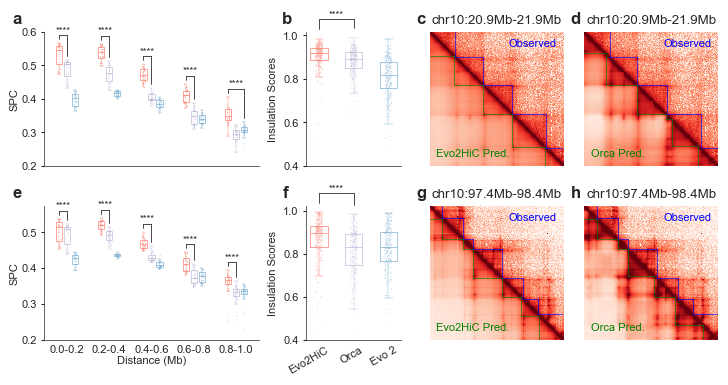

In [ ]:
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
shiftx = [-0.15, -0.25, -0.1, -0.1] * 2
shifty = [1.15, 1.15, 1.15, 1.15] * 2

for ax, label,sx,sy in zip(axes.flatten(), labels, shiftx, shifty):
    ax.text(
        sx, sy, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

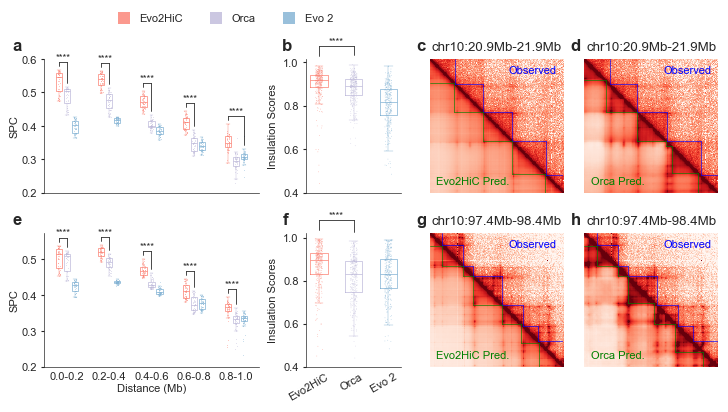

In [ ]:
pos0, pos1 = axes[0][0].get_position(), axes[0][1].get_position()
x = (pos0.x0+pos1.x1)/2
y = pos0.y1+0.1

handles, labels = axes[0][0].get_legend_handles_labels()

# 删除旧 legend（防止重复）
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()

handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
                markerfacecolor=colors[i], markeredgewidth=0, alpha=0.8,
                label=m) for i, m in enumerate(['Evo2HiC', 'Orca', 'Evo2'])]

# 在左上角单独放 legend
fig.legend(
    handles, labels,
    loc='center',
    bbox_to_anchor=(x, y),  # 锚点设在左上角稍上方
    ncol=len(labels),
    frameon=False,
    fontsize=8,           # 字体更小
    handletextpad=0.4,    # 图例符号与文字间距
    columnspacing=2,    # 各列间距
    borderaxespad=0.1     # 与轴的边界间距
)
fig

In [ ]:
fig.savefig(str(OUT_DIR / 'Fig3_HiC.pdf'))

In [ ]:
log_df = dump_test_log(str(OUT_DIR / 'Fig3_HiC_stats.tsv'))
print(log_df.to_string(index=False))